## Imports
All necessary imports are done at the start of the notebook in order to keep the file systematic and clean.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

## Data Loading

First the training, test, and sample submission files are loaded from the Kaggle Input directory.

In [2]:
train_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/train.csv')
test_df = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/test.csv')
sample_submission = pd.read_csv('/kaggle/input/mlp-term-3-2025-kaggle-assignment-3/sample_submission.csv')

## Basic Information

This section displays the structure of the training dataset.  
It includes the column names, data types, and non-null counts to help understand the overall shape and completeness of the data.


In [3]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB
None


In [4]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1700 non-null   int64  
 1   phrase     1700 non-null   object 
 2   feature_1  1478 non-null   float64
 3   feature_2  1382 non-null   float64
 4   feature_3  1610 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 66.5+ KB
None


In [5]:
print(sample_submission.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         1700 non-null   int64
 1   sentiment  1700 non-null   int64
dtypes: int64(2)
memory usage: 26.7 KB
None


## Descriptive Statistics

This section provides summary statistics for all numerical columns in the training dataset.  
It includes metrics such as count, mean, standard deviation, minimum, and maximum values.  
These help identify the range and distribution of the data, as well as any potential outliers.


In [6]:
display(train_df.describe())

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [7]:
display(test_df.describe())

,id,feature_1,feature_2,feature_3
count,1700.000000,1478.000000,1382.000000,1610.000000
mean,849.500000,19.029093,1.984805,3.449689
std,490.892045,9.203255,1.589858,2.531888
min,0.000000,2.000000,0.000000,0.000000
25%,424.750000,12.000000,1.000000,2.000000
50%,849.500000,18.000000,1.000000,3.000000
75%,1274.250000,25.000000,3.000000,5.000000
max,1699.000000,50.000000,15.000000,23.000000


In [8]:
display(sample_submission.describe())

,id,sentiment
count,1700.000000,1700.0
mean,849.500000,0.0
std,490.892045,0.0
min,0.000000,0.0
25%,424.750000,0.0
50%,849.500000,0.0
75%,1274.250000,0.0
max,1699.000000,0.0


## Checking for Missing Values and Duplicates

Before we begin preprocessing, it's important to check for any missing values or duplicate rows in the dataset.  
This helps us understand if any cleaning is required before model training.


In [9]:
print(f"\nMissing values in Training Data:\n{train_df.isnull().sum()}")
print(f"\nDuplicates in Training Dataset: {train_df.duplicated().sum()}")


Missing values in Training Data:
id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

Duplicates in Training Dataset: 0


In [10]:
print(f"\nMissing values in Test Data:\n{test_df.isnull().sum()}")
print(f"\nDuplicates in Test Dataset: {test_df.duplicated().sum()}")


Missing values in Test Data:
id             0
phrase         0
feature_1    222
feature_2    318
feature_3     90
dtype: int64

Duplicates in Test Dataset: 0


In [11]:
print(f"\nMissing values in Sample Submission Data:\n{sample_submission.isnull().sum()}")
print(f"\nDuplicates in Sample Submission Dataset: {sample_submission.duplicated().sum()}")


Missing values in Sample Submission Data:
id           0
sentiment    0
dtype: int64

Duplicates in Sample Submission Dataset: 0


## Visualizing Missing Values

To better understand the data quality, we plot a heatmap showing the locations of missing values in the dataset.  
This gives a quick visual overview of where data might be incomplete.


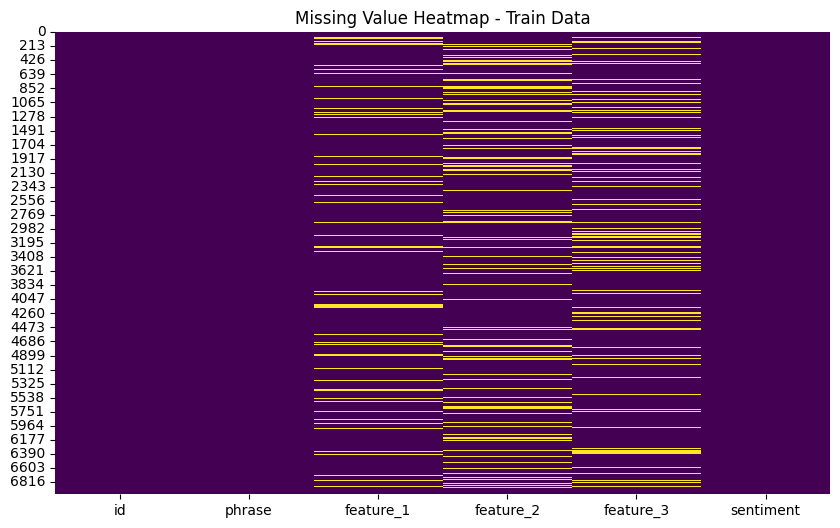

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap - Train Data")
plt.show()

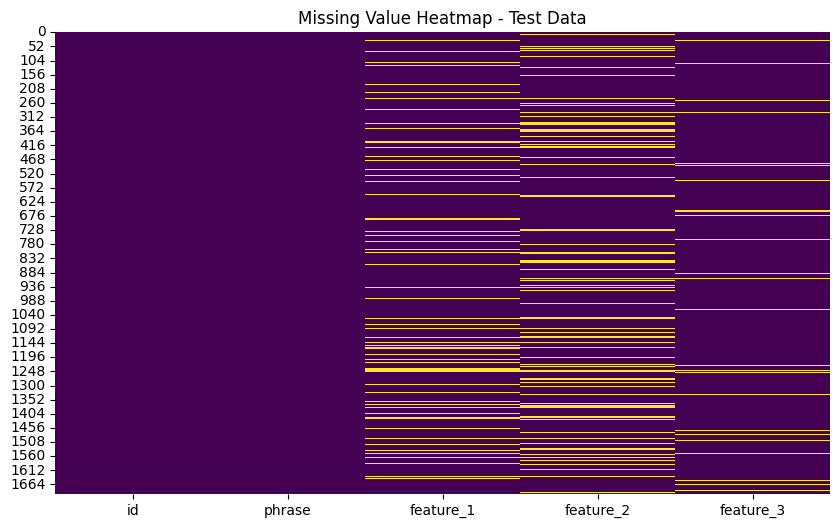

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(test_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap - Test Data")
plt.show()

## Warning Handling

As I progressed with the notbook,I saw kaggle notbook issuing some warnings.So, I later on turned of warnings with python warnings library in order to keep notebook clean.


In [14]:
import warnings
warnings.filterwarnings("ignore")

### Distributions of Numerical Features

This plot shows that feature_1 is slightly right-skewed. feature_2 and feature_3 are highly right-skewed with many low values, suggesting they are count-based features (like punctuation counts).

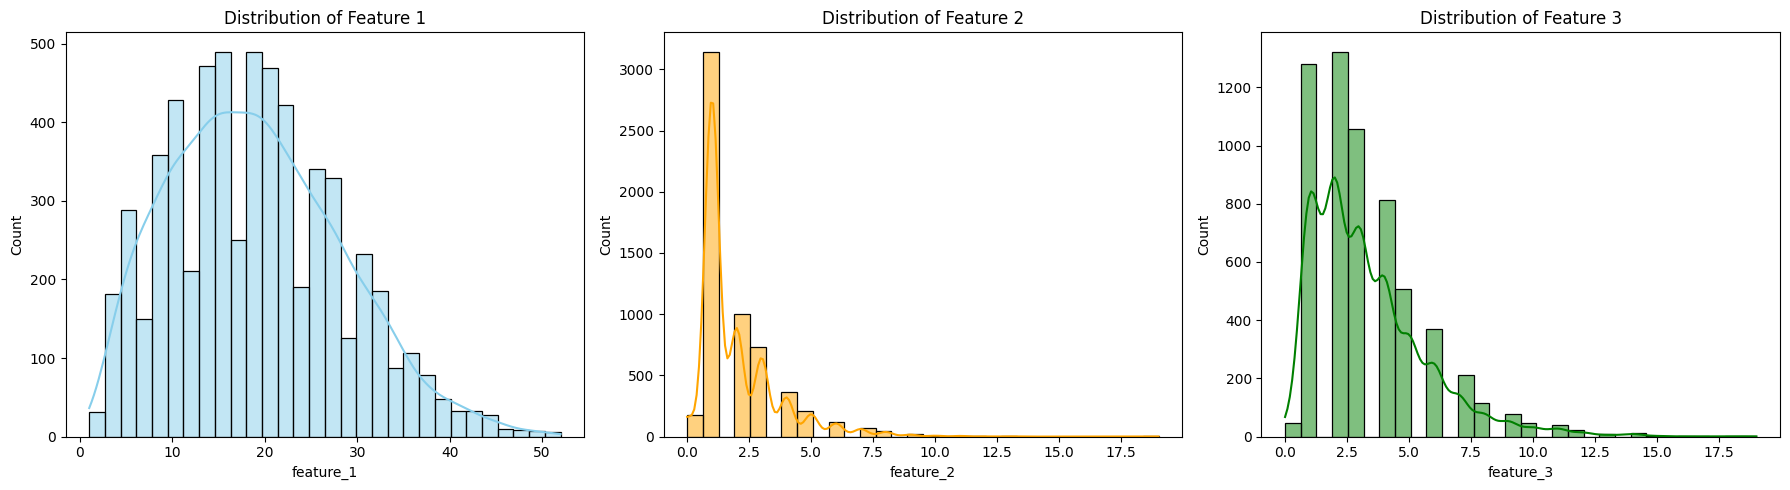

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(train_df['feature_1'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Feature 1')

sns.histplot(train_df['feature_2'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Feature 2')

sns.histplot(train_df['feature_3'], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Feature 3')

plt.tight_layout()
plt.show()

### Sentiment Distribution

Plot shows that The dataset is imbalanced. Positive (Class 2) and Negative (Class 0) sentiments are dominant, while Neutral (Class 1) is the minority class.

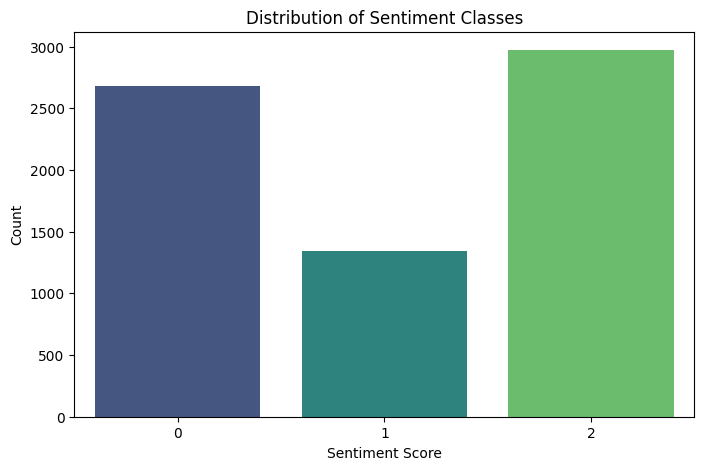

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='viridis')
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

### Numerical Features vs. Sentiment Class

There is significant overlap in the box plots across all classes. The median values for feature_1, feature_2, and feature_3 barely change between sentiments, indicating these features alone are weak predictors.

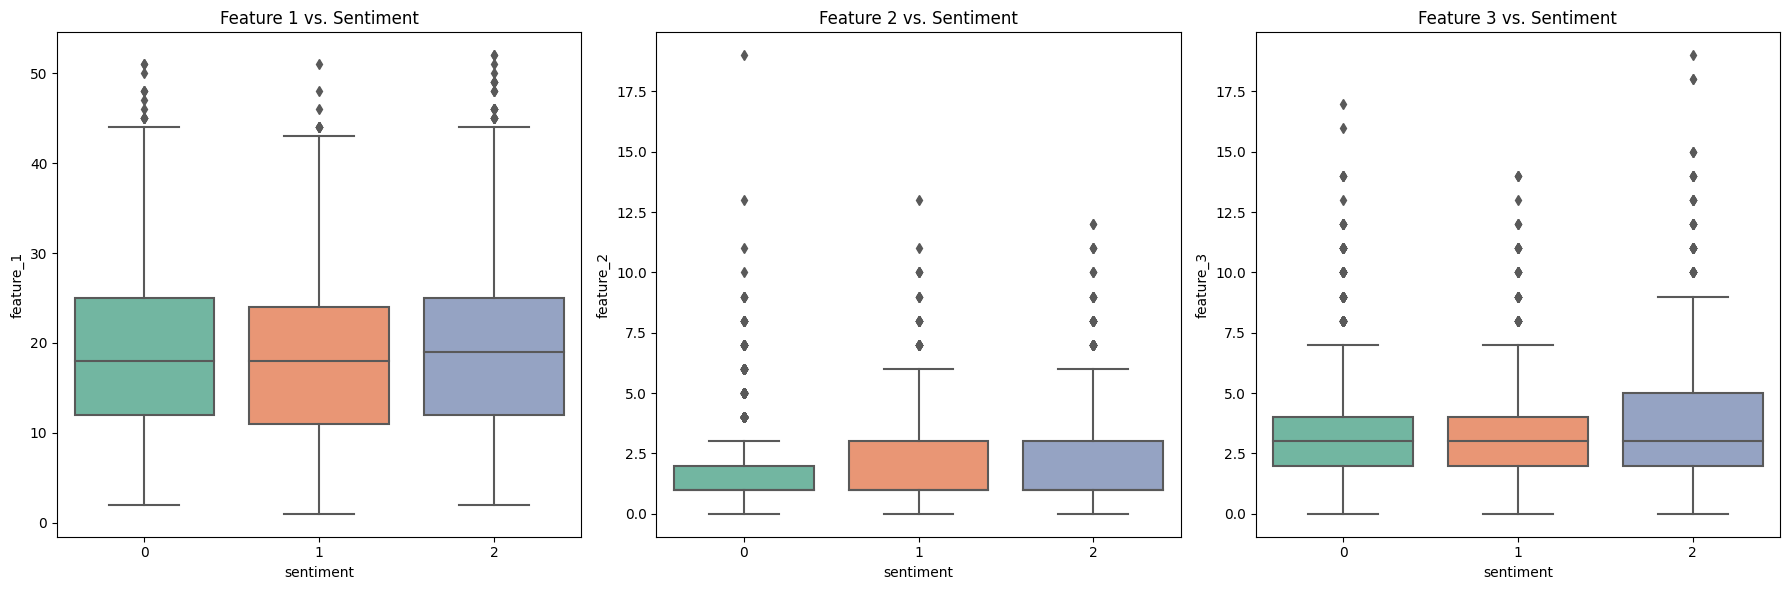

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='sentiment', y='feature_1', data=train_df, palette='Set2', ax=axes[0])
axes[0].set_title('Feature 1 vs. Sentiment')

sns.boxplot(x='sentiment', y='feature_2', data=train_df, palette='Set2', ax=axes[1])
axes[1].set_title('Feature 2 vs. Sentiment')

sns.boxplot(x='sentiment', y='feature_3', data=train_df, palette='Set2', ax=axes[2])
axes[2].set_title('Feature 3 vs. Sentiment')

plt.tight_layout()
plt.show()

### Correlation Heatmap

All numerical features have near-zero correlation with sentiment, confirming they are not linearly predictive on their own.There is a moderate correlation between feature_1 and feature_3 (0.56), suggesting longer phrases tend to have higher values for feature_3.

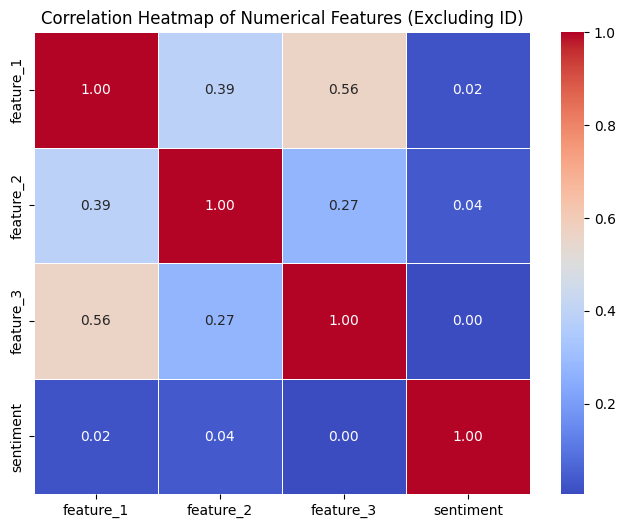

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.drop(columns=['id']).select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features (Excluding ID)')
plt.show()

## Handling Missing Values

In this section, missing values in text_col = "phrase" was handled and rest of numeric columns feature_1,feature_2 and feature_3 were handled later in encoding and feature scaling section

In [19]:
text_col = "phrase"
target = "sentiment"
id_col = "id"

train_df[text_col] = train_df[text_col].fillna("")
test_df[text_col] = test_df[text_col].fillna("")

initial_train_size = train_df.shape[0]
train_df = train_df.dropna(subset=[target])
final_train_size = train_df.shape[0]

print(f"\nDropped {initial_train_size - final_train_size} rows with missing target (if any).")

print("\nMissing values in TRAIN after handling:")
print(train_df.isnull().sum())

print("\nMissing values in TEST after handling:")
print(test_df.isnull().sum())

duplicate_rows = train_df.duplicated().sum()
print(f"\nNumber of fully duplicated rows in TRAIN: {duplicate_rows}")

duplicate_phrases = train_df.duplicated(subset=[text_col]).sum()
print(f"Number of duplicated phrases in TRAIN (same text): {duplicate_phrases}")

train_df = train_df.drop_duplicates()
print("TRAIN shape after dropping duplicate rows:", train_df.shape)



Dropped 0 rows with missing target (if any).

Missing values in TRAIN after handling:
id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

Missing values in TEST after handling:
id             0
phrase         0
feature_1    222
feature_2    318
feature_3     90
dtype: int64

Number of fully duplicated rows in TRAIN: 0
Number of duplicated phrases in TRAIN (same text): 177
TRAIN shape after dropping duplicate rows: (7000, 6)


### Handling of Duplicate Values
As checked earlier training dataset does not have duplicate values so handling is not needed

In [20]:
train_dup_phrase = train_df.duplicated(subset=[text_col]).sum()
print(f"Duplicated phrases in TRAIN (same text): {train_dup_phrase}")

train_df = train_df.drop_duplicates()
print(f"TRAIN shape after removing duplicates: {train_df.shape}")

test_dup_phrase = test_df.duplicated(subset=[text_col]).sum()
print(f"Duplicated phrases in TEST (same text): {test_dup_phrase}")

test_df = test_df.drop_duplicates()
print(f"TEST shape after removing duplicates: {test_df.shape}")


Duplicated phrases in TRAIN (same text): 177
TRAIN shape after removing duplicates: (7000, 6)
Duplicated phrases in TEST (same text): 0
TEST shape after removing duplicates: (1700, 5)


## Date Feature Engineering and Outlier Handling



In [21]:
def add_length_features(df, text_col):
    df = df.copy()
    df["review_length_chars"] = df[text_col].apply(len)
    df["review_length_words"] = df[text_col].apply(lambda x: len(str(x).split()))
    return df

train_df = add_length_features(train_df, text_col)
test_df = add_length_features(test_df, text_col)

numeric_engineered = ["review_length_chars", "review_length_words"]
numeric_cols = ["feature_1", "feature_2", "feature_3"] + numeric_engineered

print("Numeric columns used:", numeric_cols)

def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

for col in numeric_engineered:
    lb, ub = iqr_bounds(train_df[col])
    outliers = ((train_df[col] < lb) | (train_df[col] > ub)).sum()
    print(f"{col}: lower={lb:.2f}, upper={ub:.2f}, outliers={outliers}")

for col in numeric_engineered:
    lb, ub = iqr_bounds(train_df[col])
    train_df[col] = np.clip(train_df[col], lb, ub)
    test_df[col] = np.clip(test_df[col], lb, ub)

print("\nNumeric summary AFTER clipping engineered features (IQR bounds):")
display(train_df[numeric_engineered].describe())


Numeric columns used: ['feature_1', 'feature_2', 'feature_3', 'review_length_chars', 'review_length_words']
review_length_chars: lower=-53.00, upper=251.00, outliers=26
review_length_words: lower=-7.50, upper=44.50, outliers=51

Numeric summary AFTER clipping engineered features (IQR bounds):


,review_length_chars,review_length_words
count,7000.000000,7000.000000
mean,102.018000,19.004786
std,51.631402,9.253889
min,4.000000,1.000000
25%,61.000000,12.000000
50%,97.000000,18.000000
75%,137.000000,25.000000
max,251.000000,44.500000


## Splitting the Data

The dataset is split into training and validation sets. 80% of the data is used to train the models, and 20% is kept aside to test how well the models perform on unseen data.  We use `stratify=y` to ensure that the distribution of sentiment classes (Positive, Negative, Neutral) is identical in both the training and validation sets.

In [22]:
X = train_df[[text_col] + numeric_cols].copy()
y = train_df[target].copy()

print("X columns:", X.columns.tolist())

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)


X columns: ['phrase', 'feature_1', 'feature_2', 'feature_3', 'review_length_chars', 'review_length_words']
X_train shape: (5600, 6)
X_valid shape: (1400, 6)


## Encoding and Feature Scaling

Then the numerical columns feature_1,feature_2 and feature_3 were imputed with a simple imputer and text_col was encoded with TfidVectorizer because computers can't understand plain text and phrases directly.Standard Scaler was used for feature scaling. 

In [23]:
text_encoder = TfidfVectorizer(
     analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    max_features=200000
)

numeric_encoder = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("text", text_encoder, text_col),
        ("numeric", numeric_encoder, numeric_cols)
    ]
)

## Evaluation Function

This function is used to assess the performance of a trained model for a classification task.

It computes key metrics suitable for binary classification:
- **Accuracy Score**: Measures the proportion of correctly classified instances. A higher value indicates better accuracy.
- **F1 Score**: The harmonic mean of precision and recall. It's a good measure for imbalanced datasets. A value closer to 1 suggests a better balance between precision and recall.

The function will print these results and return them for easy comparison between different models.

In [24]:
def assess_model_performance(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{name}: Accuracy = {acc:.4f} | F1 Score = {f1:.4f}")
    return acc, f1

# AI Model Training and hypertuning

## Model Storage

We initialize two empty dictionaries:
- `trained_models` will hold our trained machine learning models.
- `performance_metrics` will store their evaluation results.

This setup allows us to organize and compare the performance of each model.

In [25]:
trained_models = {}
performance_metrics = {}

## Logistic Regression


In [26]:
print("\nLogistic Regression (GridSearch)")

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logisticregression", LogisticRegression(max_iter=4000,multi_class="multinomial",solver="lbfgs",n_jobs=-1))
])

param_grid_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2']
}

lr_grid = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)

lr_best = lr_grid.best_estimator_
trained_models['lr'] = lr_best

print(f"Best LR Params: {lr_grid.best_params_}")

performance_metrics['Logistic Regression'] = assess_model_performance(
    y_valid, lr_best.predict(X_valid), "Logistic Regression"
)


Logistic Regression (GridSearch)
Best LR Params: {'logisticregression__C': 1, 'logisticregression__penalty': 'l2'}
Logistic Regression: Accuracy = 0.6393 | F1 Score = 0.5898


## Linear SVC
LinearSVC is usually faster and better for high-dim text data than standard SVC

In [27]:
print("\nLinear SVC (GridSearch)")

pipe_lsvc = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('linearsvc', LinearSVC(random_state=42))
])

param_grid_lsvc = {
    'linearsvc__C': [0.01, 0.1, 1, 10, 100]
}

lsvc_grid = GridSearchCV(pipe_lsvc, param_grid_lsvc, cv=5, scoring='accuracy', n_jobs=-1)
lsvc_grid.fit(X_train, y_train)

lsvc_best = lsvc_grid.best_estimator_
trained_models['lsvc'] = lsvc_best

print(f"Best LinearSVC Params: {lsvc_grid.best_params_}")

performance_metrics['Linear SVC'] = assess_model_performance(
    y_valid, lsvc_best.predict(X_valid), "Linear SVC"
)


Linear SVC (GridSearch)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Best LinearSVC Params: {'linearsvc__C': 0.1}
Linear SVC: Accuracy = 0.6293 | F1 Score = 0.5708


## Multinomial NB Classifier

In [28]:
print("\nMultinomial Naive Bayes (GridSearch)")

pipe_mnb = Pipeline(steps=[
    ("tfidf", text_encoder),
    ("multinomialnb", MultinomialNB())
])

param_grid_mnb = {
    'multinomialnb__alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
}

mnb_grid = GridSearchCV(pipe_mnb, param_grid_mnb, cv=5, scoring='accuracy', n_jobs=-1)
mnb_grid.fit(X_train[text_col], y_train)

mnb_best = mnb_grid.best_estimator_
trained_models['mnb'] = mnb_best

print(f"Best MNB Params: {mnb_grid.best_params_}")

performance_metrics['Multinomial NB'] = assess_model_performance(
    y_valid, mnb_best.predict(X_valid[text_col]), "Multinomial NB"
)


Multinomial Naive Bayes (GridSearch)
Best MNB Params: {'multinomialnb__alpha': 0.1}
Multinomial NB: Accuracy = 0.6350 | F1 Score = 0.5949


## Random Forest Classifier

We now train a **Random Forest Classifier** and use `GridSearchCV` to find the best combination of hyperparameters such as the number of trees (`n_estimators`) and tree depth (`max_depth`).  
This model performs well on both simple and complex classification patterns.  
After identifying the best model, we evaluate its performance on the validation set and store the results.


In [29]:
print("\nRandom Forest Classifier")

rf_expanded = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_expanded.fit(X_train, y_train)
trained_models['rf_expanded'] = rf_expanded

performance_metrics['Random Forest_Expanded'] = assess_model_performance(
    y_valid,
    rf_expanded.predict(X_valid),
    "Random Forest_Expanded"
)


Random Forest Classifier
Random Forest_Expanded: Accuracy = 0.6100 | F1 Score = 0.5535


## Gradient Boosting Classifier 

This model builds trees sequentially, with each new tree correcting the errors of the previous ones.  
After determining the best configuration, we evaluate its performance on the validation set and store the results.


In [30]:
print("\nGradient Boosting Classifier")

gb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("gradientboostingclassifier", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)
gb_best = gb_pipeline

trained_models['gb'] = gb_best

performance_metrics['Gradient Boosting'] = assess_model_performance(
    y_valid,
    gb_best.predict(X_valid),
    "Gradient Boosting"
)



Gradient Boosting Classifier
Gradient Boosting: Accuracy = 0.5736 | F1 Score = 0.5241


## XGBoost Classifier

We use **XGBoost**, a powerful and efficient tree-based algorithm widely used in machine learning competitions.  
To optimize its performance, we apply `GridSearchCV` to find the best hyperparameters such as `n_estimators`, `learning_rate`, and `max_depth`.  
Once the best configuration is selected, we evaluate the model on the validation set and record its performance.


In [31]:
print("\nXGBoost Classifier")

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
trained_models['xgb'] = xgb_pipeline

performance_metrics['XGBoost'] = assess_model_performance(
    y_valid,
    xgb_pipeline.predict(X_valid),
    "XGBoost"
)


XGBoost Classifier
XGBoost: Accuracy = 0.6057 | F1 Score = 0.5710


## Support Vector Classifier

We apply a **Support Vector Classifier (SVC)**, which is effective for capturing complex decision boundaries by finding the optimal separating hyperplane between classes.  
Because SVC is sensitive to feature scaling, standardized features significantly improve its performance.  
The model is then trained and evaluated on the validation set.

In [32]:
print("\nSupport Vector Classifier")

pipe_svc = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svc", SVC(random_state=42, probability=True, C=0.1, kernel='rbf', gamma='scale'))
])

pipe_svc.fit(X_train, y_train)

svc_best = pipe_svc
trained_models['svc'] = svc_best

print(f"Trained SVC Model with fixed parameters")

performance_metrics['SVC'] = assess_model_performance(
    y_valid,
    svc_best.predict(X_valid),
    "SVC"
)



Support Vector Classifier
Trained SVC Model with fixed parameters
SVC: Accuracy = 0.4243 | F1 Score = 0.2528


## LightGBM Classifier

Next, we train a **LightGBM Classifier**, a gradient boosting framework that uses tree-based learning algorithms.  
It is known for its speed, efficiency, and strong performance, especially on large datasets.  
We train it with default parameters to provide a quick comparison against the other classification mod


In [33]:
print("\nLightGBM Classifier")
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lgbm", LGBMClassifier(random_state=42))
])
lgbm_pipe.fit(X_train, y_train)
trained_models['lgbm'] = lgbm_pipe
performance_metrics['LightGBM'] = assess_model_performance(
    y_valid, lgbm_pipe.predict(X_valid), "LightGBM"
)


LightGBM Classifier
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.632326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 391098
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 13371
[LightGBM] [Info] Start training from score -0.958695
[LightGBM] [Info] Start training from score -1.650446
[LightGBM] [Info] Start training from score -0.856507
LightGBM: Accuracy = 0.6050 | F1 Score = 0.5741


## Models with Hyperparameter Tuning

Hyperparameter tuning using Grid Search was performed on the following classification models:

- Logistic Regression
- Linear SVC
- Multinomial NB Classifier

## Model Comparison

After training all models, we compare them using two metrics:  
- **Accuracy Score**: Higher is better.  
- **F1 Score**: Higher is better, as it balances precision and recall.

This helps us identify which model performs best overall.

In [34]:
results_df = pd.DataFrame(
    performance_metrics,
    index=['Accuracy', 'F1 Score']
).T.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison after Voting Ensemble:")
print(results_df)



Model Comparison after Voting Ensemble:
                        Accuracy  F1 Score
Logistic Regression     0.639286  0.589780
Multinomial NB          0.635000  0.594885
Linear SVC              0.629286  0.570809
Random Forest_Expanded  0.610000  0.553495
XGBoost                 0.605714  0.570973
LightGBM                0.605000  0.574089
Gradient Boosting       0.573571  0.524098
SVC                     0.424286  0.252784


# Final Model and Submission

Based on the model comparison, we select **Gradient Boosting** as the final model due to its strong performance on the validation data (lowest RMSE).\
The chosen model is retrained using the full training and validation sets to maximize learning.\
Finally, we make predictions on the test data and prepare the submission file.

In [35]:
best_model_name = results_df['Accuracy'].idxmax()
best_score = results_df.loc[best_model_name, 'Accuracy']
print(f"Choosing '{best_model_name}' as the final model (Accuracy: {best_score:.4f}).")

model_name_mapping = {
    'Logistic Regression': 'lr',
    'Linear SVC': 'lsvc',
    'Multinomial NB': 'mnb',
    'Random Forest_Expanded': 'rf_expanded',
    'Gradient Boosting': 'gb',
    'XGBoost': 'xgb',
    'SVC': 'svc',
    'LightGBM': 'lgbm'
}


model_key = model_name_mapping.get(best_model_name)
if model_key not in trained_models:
    raise ValueError(f"Model key '{model_key}' not found in trained_models. Available keys: {list(trained_models.keys())}")

final_model = trained_models[model_key]
print(f"Retraining {best_model_name} on the full dataset...")

final_model.fit(X, y)
final_predictions = final_model.predict(test_df[[text_col] + numeric_cols])

submission = pd.DataFrame({
    'id': test_df['id'],
    'sentiment': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")
display(submission.head())

Choosing 'Logistic Regression' as the final model (Accuracy: 0.6393).
Retraining Logistic Regression on the full dataset...
Submission file 'submission.csv' created successfully.


,id,sentiment
0,0,0
1,1,2
2,2,2
3,3,2
4,4,0
